# 04 — Irradiance quality control and filtered datasets

This notebook applies the irradiance quality-control stage to the repaired 2017–2021 dataset.

The purpose of this notebook is to:

1. generate a clear-sky plane-of-array irradiance reference using the final array geometry
2. classify days by irradiance condition
3. visualise representative measured and clear-sky irradiance profiles
4. create the row-level irradiance-filtered datasets used in later PR and PLR calculations

The output datasets are `g200`, `g400`, and `sunny`.

## 1. Imports and plotting styles

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------------
# Plotting style
# ---------------------------------------------------------------------

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,

    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 12,
    "legend.title_fontsize": 12,

    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.7,
})

TITLE_SIZE = 16
SUBTITLE_SIZE = 14
AXIS_LABEL_SIZE = 12
LEGEND_SIZE = 12

## 2. Project paths

The notebook reads the repaired dataset from the physical plausibility filtering stage

In [2]:
PROJECT_ROOT = Path("C:/Users/amina/Thesis/Final Pipeline")

DIRS = {
    "data_intermediate": PROJECT_ROOT / "data_intermediate",
    "data_processed": PROJECT_ROOT / "data_processed",
    "figures": PROJECT_ROOT / "figures",
    "tables": PROJECT_ROOT / "tables",
}

FINAL_FIG_DIR = DIRS["figures"] / "final figures"
FINAL_TABLE_DIR = DIRS["tables"] / "final tables"
IRRADIANCE_OUTPUT_DIR = DIRS["data_processed"] / "irradiance_qc"

for folder in [DIRS["data_processed"], FINAL_FIG_DIR, FINAL_TABLE_DIR, IRRADIANCE_OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

REPAIRED_INPUT_PATH = DIRS["data_intermediate"] / "df_plr_repaired.parquet"

IRRADIANCE_QC_OUTPUT_PATH = IRRADIANCE_OUTPUT_DIR / "df_irradiance_qc.parquet"
G200_OUTPUT_PATH = IRRADIANCE_OUTPUT_DIR / "df_g200.parquet"
G400_OUTPUT_PATH = IRRADIANCE_OUTPUT_DIR / "df_g400.parquet"
SUNNY_OUTPUT_PATH = IRRADIANCE_OUTPUT_DIR / "df_sunny.parquet"

print("Project root:", PROJECT_ROOT)
print("Input dataset:", REPAIRED_INPUT_PATH)
print("Irradiance output folder:", IRRADIANCE_OUTPUT_DIR)
print("Figure folder:", FINAL_FIG_DIR)
print("Table folder:", FINAL_TABLE_DIR)

Project root: C:\Users\amina\Thesis\Final Pipeline
Input dataset: C:\Users\amina\Thesis\Final Pipeline\data_intermediate\df_plr_repaired.parquet
Irradiance output folder: C:\Users\amina\Thesis\Final Pipeline\data_processed\irradiance_qc
Figure folder: C:\Users\amina\Thesis\Final Pipeline\figures\final figures
Table folder: C:\Users\amina\Thesis\Final Pipeline\tables\final tables


## 3. Helper functions

In [3]:
def save_fig(filename, fig=None):
    """
    Save the active figure to the final figure directory.
    """
    if fig is None:
        fig = plt.gcf()

    out_path = FINAL_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight", dpi=300)
    print("Saved:", out_path)


def find_irradiance_column(df_input):
    """
    Return the irradiance column used as measured plane-of-array irradiance.
    """
    candidate_columns = ["G_POA", "POA_GLOBAL", "G"]

    for col in candidate_columns:
        if col in df_input.columns:
            return col

    raise KeyError(
        "No irradiance column found. Expected one of: G_POA, POA_GLOBAL, or G."
    )


def ensure_datetime_columns(df_input):
    """
    Standardise datetime columns used in the irradiance QC notebook.
    """
    df_output = df_input.copy()

    df_output["Datetime_Bin_Local"] = pd.to_datetime(df_output["Datetime_Bin_Local"])

    if "Datetime_Bin_UTC" in df_output.columns:
        df_output["Datetime_Bin_UTC"] = pd.to_datetime(
            df_output["Datetime_Bin_UTC"],
            utc=True,
        )
    else:
        local_time = pd.to_datetime(df_output["Datetime_Bin_Local"])

        if local_time.dt.tz is None:
            local_time = local_time.dt.tz_localize(TZ_LOCAL)

        df_output["Datetime_Bin_UTC"] = local_time.dt.tz_convert("UTC")

    df_output["Date_Local"] = (
        df_output["Datetime_Bin_Local"]
        .dt.tz_localize(None)
        .dt.floor("D")
    )

    return df_output

## 4. Constants and module metadata

The final array azimuth used for clear-sky POA modelling is 205°. No azimuth sensitivity analysis is carried out in this final notebook.

In [5]:
TZ_LOCAL = "Europe/Copenhagen"

SITE_LATITUDE = 55.6867
SITE_LONGITUDE = 12.0986

ARRAY_TILT_DEG = 60
ARRAY_AZIMUTH_DEG = 205

ANALYSIS_START = "2017-01-01"
ANALYSIS_END = "2021-12-31"

G200_THRESHOLD = 200
G400_THRESHOLD = 400
G_POA_MAX = 1200

SUNNY_DAY_CLASSES = [
    "Near clear-sky",
    "Partly clear / variable",
]

CLASS_ORDER = [
    "Near clear-sky",
    "Partly clear / variable",
    "Highly variable",
    "Cloudy / low irradiance",
    "Incomplete / low coverage",
]

CLASS_COLORS = {
    "Near clear-sky": "#0072B2",
    "Partly clear / variable": "#009E73",
    "Highly variable": "#E69F00",
    "Cloudy / low irradiance": "#999999",
    "Incomplete / low coverage": "#CC79A7",
}

In [6]:
module_meta = pd.DataFrame({
    "Module_ID": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Type": [
        "PID/Reference",
        "Reference",
        "uCrack",
        "uCrack",
        "Reference",
        "uCrack",
        "uCrack",
        "uCrack",
        "uCrack",
        "Reference",
    ],
})

TYPE_COLORS = {
    "Reference": "#009E73",
    "PID/Reference": "#0072B2",
    "uCrack": "#D55E00",
}

module_meta["Color"] = module_meta["Type"].map(TYPE_COLORS)

MODULE_TYPE_MAP = dict(zip(module_meta["Module_ID"], module_meta["Type"]))
MODULE_COLOR_MAP = dict(zip(module_meta["Module_ID"], module_meta["Color"]))

display(module_meta)

,Module_ID,Type,Color
0,1,PID/Reference,#0072B2
1,2,Reference,#009E73
2,3,uCrack,#D55E00
3,4,uCrack,#D55E00
4,5,Reference,#009E73
5,6,uCrack,#D55E00
6,7,uCrack,#D55E00
7,8,uCrack,#D55E00
8,9,uCrack,#D55E00
9,10,Reference,#009E73


## 5. Load repaired dataset

The repaired physical plausibility dataset is loaded from Notebook 03. The measured irradiance column is standardised as `G_POA` for the rest of this notebook.

In [7]:
df = pd.read_parquet(REPAIRED_INPUT_PATH)
df = ensure_datetime_columns(df)

irradiance_col = find_irradiance_column(df)

if irradiance_col != "G_POA":
    df["G_POA"] = df[irradiance_col]

df = df.sort_values(["Module_ID", "Datetime_Bin_Local"]).reset_index(drop=True)

print("Loaded repaired dataset.")
print("Shape:", df.shape)
print("Irradiance column used:", irradiance_col)
print("Monitoring period:", df["Datetime_Bin_Local"].min(), "to", df["Datetime_Bin_Local"].max())
print("Modules:", sorted(df["Module_ID"].unique()))

display(df.head())

Loaded repaired dataset.
Shape: (5519872, 29)
Irradiance column used: POA_GLOBAL
Monitoring period: 2017-01-01 11:45:00+01:00 to 2021-12-31 16:30:00+01:00
Modules: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


,Module_ID,UnixTime,G,MPP,VMP,VOC,ISC,IMP,Temp,Change_In_Light,...,DayOfYear,YearMonth,Datetime_Bin_Local,Datetime_Bin_UTC,Temp_Original,Temp_Invalid_Original,Temp_Replaced,Temp_Repair_Source,Date_Local,G_POA
0,1,1483267776,22.650404,2.862897,16.443495,20.411654,0.191721,0.174105,7.152748,-0.002161,...,1,2017-01,2017-01-01 11:45:00+01:00,2017-01-01 10:45:00+00:00,7.152748,False,False,None,2017-01-01,22.650404
1,1,1483267932,22.079516,3.011066,16.448720,20.472158,0.199819,0.183058,7.172724,0.003791,...,1,2017-01,2017-01-01 11:45:00+01:00,2017-01-01 10:45:00+00:00,7.172724,False,False,None,2017-01-01,22.079516
2,1,1483268089,23.149010,3.162558,17.341951,20.527380,0.209408,0.182365,7.191124,-0.000558,...,1,2017-01,2017-01-01 11:45:00+01:00,2017-01-01 10:45:00+00:00,7.191124,False,False,None,2017-01-01,23.149010
3,1,1483268245,24.266972,3.317965,17.356859,20.579874,0.218623,0.191162,7.238706,-0.001440,...,1,2017-01,2017-01-01 11:45:00+01:00,2017-01-01 10:45:00+00:00,7.238706,False,False,None,2017-01-01,24.266972
4,1,1483268409,23.540920,3.147193,17.340786,20.515538,0.209560,0.181491,7.191426,-0.009764,...,1,2017-01,2017-01-01 12:00:00+01:00,2017-01-01 11:00:00+00:00,7.191426,False,False,None,2017-01-01,23.540920


## 6. Build measured irradiance time series

The measured irradiance signal is collapsed to one value per 15-minute time bin using the median across modules. This avoids repeated module rows when comparing measured irradiance with the clear-sky POA reference.

In [8]:
irr_ts = (
    df.groupby(["Datetime_Bin_UTC", "Datetime_Bin_Local"], as_index=False)
    .agg(G_POA_measured=("G_POA", "median"))
)

irr_ts["Date_Local"] = (
    irr_ts["Datetime_Bin_Local"]
    .dt.tz_localize(None)
    .dt.floor("D")
)

print("Irradiance time-series shape:", irr_ts.shape)
display(irr_ts.head())

Irradiance time-series shape: (70743, 4)


,Datetime_Bin_UTC,Datetime_Bin_Local,G_POA_measured,Date_Local
0,2017-01-01 10:45:00+00:00,2017-01-01 11:45:00+01:00,23.136339,2017-01-01
1,2017-01-01 11:00:00+00:00,2017-01-01 12:00:00+01:00,23.910483,2017-01-01
2,2017-01-01 11:15:00+00:00,2017-01-01 12:15:00+01:00,23.873161,2017-01-01
3,2017-01-01 11:30:00+00:00,2017-01-01 12:30:00+01:00,34.837397,2017-01-01
4,2017-01-01 11:45:00+00:00,2017-01-01 12:45:00+01:00,63.235565,2017-01-01


## 7. Generate clear-sky POA irradiance

A clear-sky POA reference is generated using the final site location and array geometry. This reference is used only for irradiance classification and visual diagnostics.

In [9]:
try:
    import pvlib
except ImportError as exc:
    raise ImportError(
        "pvlib is required for clear-sky irradiance modelling. "
        "Install it with: pip install pvlib"
    ) from exc

In [13]:
def calculate_clear_sky_poa(time_index_utc):
    """
    Calculate clear-sky plane-of-array irradiance for the site and final array geometry.
    """

    time_index_utc = pd.DatetimeIndex(
        pd.to_datetime(time_index_utc, utc=True)
    )

    location = pvlib.location.Location(
        latitude=SITE_LATITUDE,
        longitude=SITE_LONGITUDE,
        tz="UTC",
    )

    clear_sky = location.get_clearsky(time_index_utc, model="ineichen")
    solar_position = location.get_solarposition(time_index_utc)

    poa = pvlib.irradiance.get_total_irradiance(
        surface_tilt=ARRAY_TILT_DEG,
        surface_azimuth=ARRAY_AZIMUTH_DEG,
        solar_zenith=solar_position["apparent_zenith"],
        solar_azimuth=solar_position["azimuth"],
        dni=clear_sky["dni"],
        ghi=clear_sky["ghi"],
        dhi=clear_sky["dhi"],
    )

    return pd.Series(
        poa["poa_global"].clip(lower=0).to_numpy(),
        index=time_index_utc,
        name="G_POA_clear_sky",
    )

In [14]:
start_utc = pd.Timestamp(ANALYSIS_START, tz=TZ_LOCAL).tz_convert("UTC")

end_utc = (
    pd.Timestamp(ANALYSIS_END, tz=TZ_LOCAL)
    + pd.Timedelta(days=1)
    - pd.Timedelta(minutes=15)
).tz_convert("UTC")

full_time_grid_utc = pd.date_range(
    start=start_utc,
    end=end_utc,
    freq="15min",
    tz="UTC",
)

irr_grid = pd.DataFrame({
    "Datetime_Bin_UTC": full_time_grid_utc,
})

irr_grid["Datetime_Bin_Local"] = irr_grid["Datetime_Bin_UTC"].dt.tz_convert(TZ_LOCAL)

irr_grid["Date_Local"] = (
    irr_grid["Datetime_Bin_Local"]
    .dt.tz_localize(None)
    .dt.floor("D")
)

clear_sky_poa = calculate_clear_sky_poa(full_time_grid_utc)

irr_grid["G_POA_clear_sky"] = clear_sky_poa.to_numpy()

irr_grid = irr_grid.merge(
    irr_ts[["Datetime_Bin_UTC", "G_POA_measured"]],
    on="Datetime_Bin_UTC",
    how="left",
)

display(irr_grid.head())

,Datetime_Bin_UTC,Datetime_Bin_Local,Date_Local,G_POA_clear_sky,G_POA_measured
0,2016-12-31 23:00:00+00:00,2017-01-01 00:00:00+01:00,2017-01-01,0.0,NaN
1,2016-12-31 23:15:00+00:00,2017-01-01 00:15:00+01:00,2017-01-01,0.0,NaN
2,2016-12-31 23:30:00+00:00,2017-01-01 00:30:00+01:00,2017-01-01,0.0,NaN
3,2016-12-31 23:45:00+00:00,2017-01-01 00:45:00+01:00,2017-01-01,0.0,NaN
4,2017-01-01 00:00:00+00:00,2017-01-01 01:00:00+01:00,2017-01-01,0.0,NaN


## 8. Add daylight bin flags

To help identify which bins are considered part of daytime. For shading diagnostic analysis in the future. 

1. `is_daytime_solar`: bins where apparent solar elevation is greater than 0°;
2. `is_daylight_analysis_bin`: bins where clear-sky POA irradiance is at least 50 W/m².

In [15]:
DAYTIME_CLEAR_SKY_MIN = 50  # W/m²; avoids sunrise/sunset ratio instability

solar_position = pvlib.solarposition.get_solarposition(
    time=pd.DatetimeIndex(irr_grid["Datetime_Bin_UTC"]),
    latitude=SITE_LATITUDE,
    longitude=SITE_LONGITUDE,
)

irr_grid["solar_apparent_elevation_deg"] = solar_position["apparent_elevation"].to_numpy()

irr_grid["is_daytime_solar"] = (
    irr_grid["solar_apparent_elevation_deg"] > 0
)

irr_grid["is_daylight_analysis_bin"] = (
    irr_grid["G_POA_clear_sky"] >= DAYTIME_CLEAR_SKY_MIN
)

display(
    irr_grid[
        [
            "Datetime_Bin_UTC",
            "Datetime_Bin_Local",
            "G_POA_clear_sky",
            "G_POA_measured",
            "solar_apparent_elevation_deg",
            "is_daytime_solar",
            "is_daylight_analysis_bin",
        ]
    ].head()
)

,Datetime_Bin_UTC,Datetime_Bin_Local,G_POA_clear_sky,G_POA_measured,solar_apparent_elevation_deg,is_daytime_solar,is_daylight_analysis_bin
0,2016-12-31 23:00:00+00:00,2017-01-01 00:00:00+01:00,0.0,NaN,-57.198934,False,False
1,2016-12-31 23:15:00+00:00,2017-01-01 00:15:00+01:00,0.0,NaN,-57.316192,False,False
2,2016-12-31 23:30:00+00:00,2017-01-01 00:30:00+01:00,0.0,NaN,-57.198237,False,False
3,2016-12-31 23:45:00+00:00,2017-01-01 00:45:00+01:00,0.0,NaN,-56.847789,False,False
4,2017-01-01 00:00:00+00:00,2017-01-01 01:00:00+01:00,0.0,NaN,-56.272736,False,False


## 9. Classify irradiance conditions

Days are classified by comparing measured POA irradiance with the modelled clear-sky POA reference. The classification is used to identify near clear-sky, partly clear, highly variable, cloudy, and incomplete days.

The classification supports the sunny-day sensitivity dataset and provides appendix figures showing the irradiance conditions present in the monitoring record.

In [16]:
MIN_DAYTIME_COVERAGE = 0.60

NEAR_CLEAR_MIN_ENERGY_RATIO = 0.72
NEAR_CLEAR_MAX_VARIABILITY = 1.60
NEAR_CLEAR_MAX_MAE_NORM = 0.22

PARTLY_CLEAR_MIN_ENERGY_RATIO = 0.50
PARTLY_CLEAR_MAX_VARIABILITY = 2.50

CLOUDY_MAX_ENERGY_RATIO = 0.35
CLOUDY_MAX_PEAK_IRRADIANCE = 350

CLASS_ORDER = [
    "Near clear-sky",
    "Partly clear / variable",
    "Highly variable",
    "Cloudy / low irradiance",
    "Incomplete / low coverage",
]

CLASS_COLORS = {
    "Near clear-sky": "#0072B2",
    "Partly clear / variable": "#009E73",
    "Highly variable": "#E69F00",
    "Cloudy / low irradiance": "#999999",
    "Incomplete / low coverage": "#CC79A7",
}

SUNNY_DAY_CLASSES = [
    "Near clear-sky",
    "Partly clear / variable",
]

In [17]:
def classify_one_day(day_df):
    """
    Classify one day using measured and clear-sky POA irradiance.
    """

    daytime = day_df.loc[day_df["is_daylight_analysis_bin"]].copy()

    if len(daytime) == 0:
        return pd.Series({
            "expected_daytime_bins": 0,
            "observed_daytime_bins": 0,
            "coverage_pct": np.nan,
            "energy_ratio": np.nan,
            "variability_index": np.nan,
            "mae_norm": np.nan,
            "peak_measured_G_POA": np.nan,
            "Irradiance_Class": "Incomplete / low coverage",
        })

    observed = daytime["G_POA_measured"].notna()
    coverage = observed.mean()

    if coverage < MIN_DAYTIME_COVERAGE:
        return pd.Series({
            "expected_daytime_bins": len(daytime),
            "observed_daytime_bins": int(observed.sum()),
            "coverage_pct": 100 * coverage,
            "energy_ratio": np.nan,
            "variability_index": np.nan,
            "mae_norm": np.nan,
            "peak_measured_G_POA": daytime["G_POA_measured"].max(),
            "Irradiance_Class": "Incomplete / low coverage",
        })

    measured = daytime["G_POA_measured"].interpolate(limit_direction="both").clip(lower=0)
    clear_sky = daytime["G_POA_clear_sky"].clip(lower=0)

    measured_energy = measured.sum()
    clear_sky_energy = clear_sky.sum()

    energy_ratio = measured_energy / clear_sky_energy if clear_sky_energy > 0 else np.nan

    measured_variation = measured.diff().abs().sum()
    clear_sky_variation = clear_sky.diff().abs().sum()

    variability_index = (
        measured_variation / clear_sky_variation
        if clear_sky_variation > 0
        else np.nan
    )

    mae_norm = (
        (measured - clear_sky).abs().mean() / clear_sky.max()
        if clear_sky.max() > 0
        else np.nan
    )

    peak_measured = measured.max()

    if (energy_ratio < CLOUDY_MAX_ENERGY_RATIO) or (peak_measured < CLOUDY_MAX_PEAK_IRRADIANCE):
        day_class = "Cloudy / low irradiance"
    elif (
        energy_ratio >= NEAR_CLEAR_MIN_ENERGY_RATIO
        and variability_index <= NEAR_CLEAR_MAX_VARIABILITY
        and mae_norm <= NEAR_CLEAR_MAX_MAE_NORM
    ):
        day_class = "Near clear-sky"
    elif (
        energy_ratio >= PARTLY_CLEAR_MIN_ENERGY_RATIO
        and variability_index <= PARTLY_CLEAR_MAX_VARIABILITY
    ):
        day_class = "Partly clear / variable"
    else:
        day_class = "Highly variable"

    return pd.Series({
        "expected_daytime_bins": len(daytime),
        "observed_daytime_bins": int(observed.sum()),
        "coverage_pct": 100 * coverage,
        "energy_ratio": energy_ratio,
        "variability_index": variability_index,
        "mae_norm": mae_norm,
        "peak_measured_G_POA": peak_measured,
        "Irradiance_Class": day_class,
    })

In [18]:
day_classification = (
    irr_grid
    .groupby("Date_Local")
    .apply(classify_one_day)
    .reset_index()
)

day_classification["Irradiance_Class"] = pd.Categorical(
    day_classification["Irradiance_Class"],
    categories=CLASS_ORDER,
    ordered=True,
)

class_counts = (
    day_classification["Irradiance_Class"]
    .value_counts()
    .reindex(CLASS_ORDER, fill_value=0)
    .rename_axis("Irradiance_Class")
    .reset_index(name="n_days")
)

class_counts["pct_days"] = (
    100 * class_counts["n_days"] / class_counts["n_days"].sum()
)

display(class_counts)

day_classification.to_csv(
    FINAL_TABLE_DIR / "irradiance_day_classification.csv",
    index=False,
)

class_counts.to_csv(
    FINAL_TABLE_DIR / "irradiance_day_class_counts.csv",
    index=False,
)

,Irradiance_Class,n_days,pct_days
0,Near clear-sky,209,11.445783
1,Partly clear / variable,207,11.336254
2,Highly variable,431,23.603505
3,Cloudy / low irradiance,550,30.120482
4,Incomplete / low coverage,429,23.493976


## 10. Plot irradiance class counts

This figure summarises the distribution of irradiance conditions across the selected 2017–2021 analysis window.

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_irradiance_day_class_counts.png


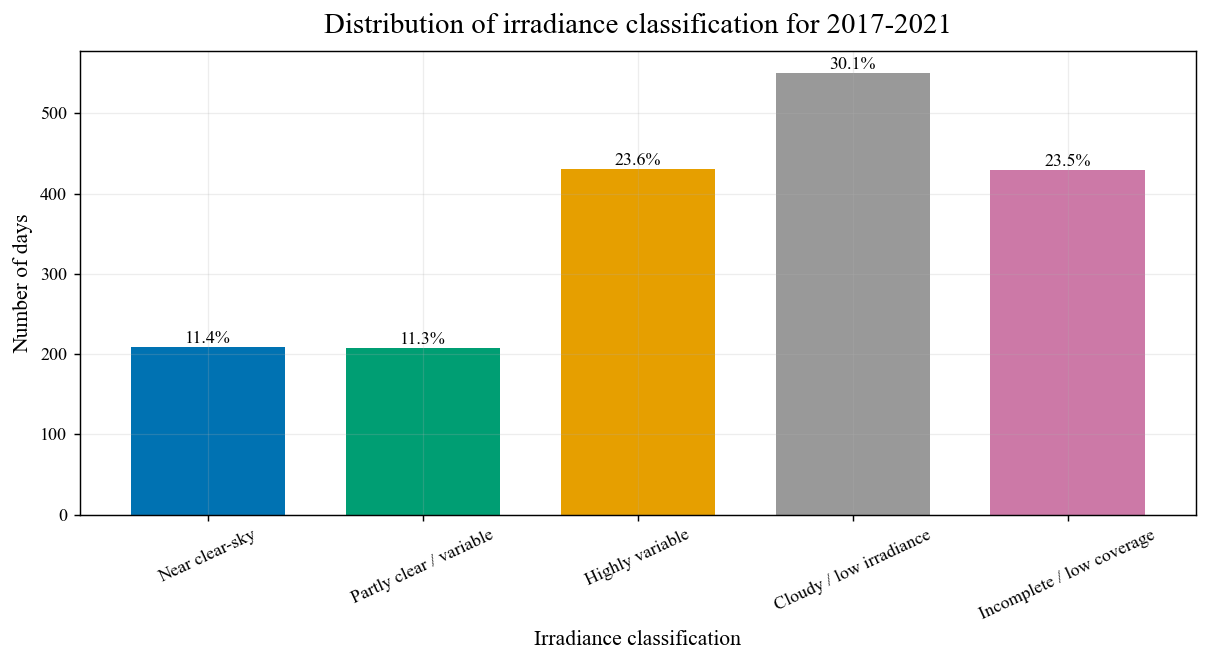

In [20]:
def plot_irradiance_class_counts(
    class_counts_input,
    save_name="appendix_irradiance_day_class_counts.png",
):
    plot_df = class_counts_input.copy()
    plot_df["Irradiance_Class"] = pd.Categorical(
        plot_df["Irradiance_Class"],
        categories=CLASS_ORDER,
        ordered=True,
    )

    plot_df = plot_df.sort_values("Irradiance_Class")

    fig, ax = plt.subplots(figsize=(9.4, 5.2))

    colors = [CLASS_COLORS[label] for label in plot_df["Irradiance_Class"].astype(str)]

    bars = ax.bar(
        plot_df["Irradiance_Class"].astype(str),
        plot_df["n_days"],
        color=colors,
        width=0.72,
    )

    ax.set_title(
        "Distribution of irradiance classification for 2017-2021",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.set_xlabel("Irradiance classification", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel("Number of days", fontsize=AXIS_LABEL_SIZE)

    ax.tick_params(axis="x", rotation=25)

    for bar, pct in zip(bars, plot_df["pct_days"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{pct:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
        )

    fig.tight_layout()
    save_fig(save_name, fig)
    plt.show()


plot_irradiance_class_counts(class_counts)

## 11. Plot measured and clear-sky profile example

A representative near clear-sky day is plotted to show the comparison between measured POA irradiance and the modelled clear-sky POA profile. This figure is used as an appendix diagnostic for the irradiance-classification workflow.

In [21]:
def plot_single_irradiance_day(
    day,
    title=None,
    save_name=None,
):
    """
    Plot measured and clear-sky POA irradiance for one selected day.
    """

    day = pd.Timestamp(day).floor("D")

    plot_df = irr_grid.loc[irr_grid["Date_Local"] == day].copy()

    if plot_df.empty:
        raise ValueError(f"No irradiance data found for {day.date()}")

    fig, ax = plt.subplots(figsize=(9.4, 5.4))

    ax.plot(
        plot_df["Datetime_Bin_Local"],
        plot_df["G_POA_clear_sky"],
        color="#BDBDBD",
        linewidth=2.2,
        label="Clear-sky POA model",
    )

    ax.plot(
        plot_df["Datetime_Bin_Local"],
        plot_df["G_POA_measured"],
        color="#0072B2",
        linewidth=2.0,
        label="Measured POA irradiance",
    )

    if title is None:
        title = rf"Measured and clear-sky $G_\mathrm{{POA}}$ profile on {day.strftime('%d %B %Y')}"

    ax.set_title(title, fontsize=TITLE_SIZE, pad=10)
    ax.set_xlabel("Local time of day [h]", fontsize=AXIS_LABEL_SIZE)
    ax.set_ylabel(r"$G_\mathrm{POA}$ [W/m$^2$]", fontsize=AXIS_LABEL_SIZE)

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    ax.legend(
        loc="upper right",
        frameon=True,
        fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    if save_name is not None:
        save_fig(save_name, fig)

    plt.show()

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_measured_clear_sky_poa_profile_2017_05_02.png


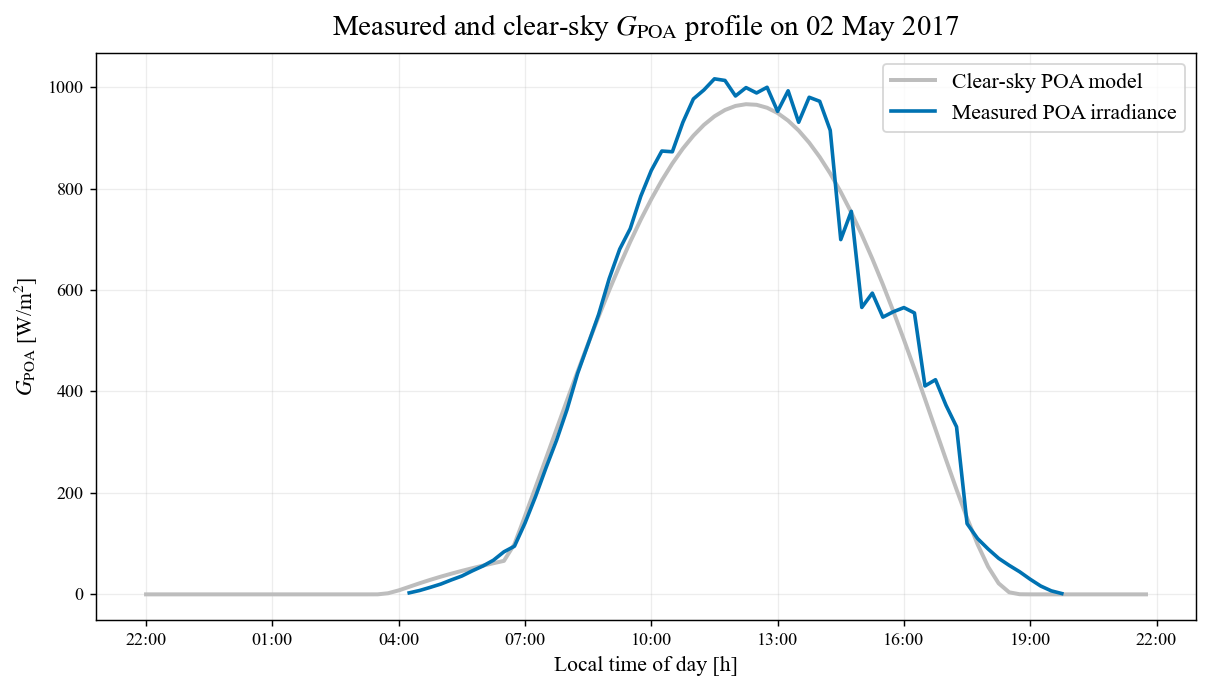

In [22]:
plot_single_irradiance_day(
    day="2017-05-02",
    title=r"Measured and clear-sky $G_\mathrm{POA}$ profile on 02 May 2017",
    save_name="appendix_measured_clear_sky_poa_profile_2017_05_02.png",
)

## 12. Plot representative examples by irradiance class

One representative day is selected from each irradiance class. These examples are saved as appendix figures to show how the classification separates near clear-sky, partly clear, variable, cloudy, and incomplete conditions.

In [23]:
def select_representative_days(day_classification_input):
    """
    Select one representative day from each irradiance class.
    """

    selected = {}

    for class_name in CLASS_ORDER:
        tmp = day_classification_input.loc[
            day_classification_input["Irradiance_Class"] == class_name
        ].copy()

        if tmp.empty:
            continue

        tmp = tmp.dropna(subset=["coverage_pct"]).copy()

        if tmp.empty:
            continue

        if tmp["energy_ratio"].notna().any():
            median_energy = tmp["energy_ratio"].median()

            tmp["selection_score"] = (
                (tmp["energy_ratio"] - median_energy).abs()
                + (100 - tmp["coverage_pct"]) / 100
            )
        else:
            tmp["selection_score"] = (100 - tmp["coverage_pct"]) / 100

        selected[class_name] = tmp.sort_values("selection_score").iloc[0]["Date_Local"]

    return selected


representative_days = select_representative_days(day_classification)

display(pd.DataFrame(
    [{"Irradiance_Class": key, "Representative_Date": value} for key, value in representative_days.items()]
))

,Irradiance_Class,Representative_Date
0,Near clear-sky,2020-06-15
1,Partly clear / variable,2019-04-06
2,Highly variable,2017-03-21
3,Cloudy / low irradiance,2018-09-11
4,Incomplete / low coverage,2021-03-18


In [33]:
def plot_single_irradiance_class_example(
    class_name,
    representative_days_input,
    save_name=None,
):
    """
    Plot one thesis-ready measured vs. clear-sky POA irradiance profile
    for a representative day from a given irradiance class.
    """

    if class_name not in representative_days_input:
        raise ValueError(f"No representative day found for class: {class_name}")

    day = pd.Timestamp(representative_days_input[class_name]).floor("D")

    plot_df = irr_grid.loc[irr_grid["Date_Local"] == day].copy()

    if plot_df.empty:
        raise ValueError(f"No irradiance data available for {day.date()}")

    fig, ax = plt.subplots(figsize=(10.5, 5.8))

    ax.plot(
        plot_df["Datetime_Bin_Local"],
        plot_df["G_POA_clear_sky"],
        color="#BDBDBD",
        linewidth=2.4,
        label="Clear-sky POA model",
        zorder=2,
    )

    ax.plot(
        plot_df["Datetime_Bin_Local"],
        plot_df["G_POA_measured"],
        color="#0072B2",
        linewidth=2.2,
        label="Measured POA irradiance",
        zorder=3,
    )

    ax.set_title(
        f"{class_name} irradiance profile on {day.strftime('%d %B %Y')}",
        fontsize=TITLE_SIZE,
        pad=10,
    )

    ax.set_xlabel(
        "Local time of day [h]",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.set_ylabel(
        r"$G_\mathrm{POA}$ [W/m$^2$]",
        fontsize=AXIS_LABEL_SIZE,
    )

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

    ax.legend(
        loc="upper right",
        frameon=True,
        fontsize=LEGEND_SIZE,
    )

    fig.tight_layout()

    if save_name is not None:
        save_fig(save_name, fig)

    plt.show()

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_near_clear_sky_irradiance_profile.png


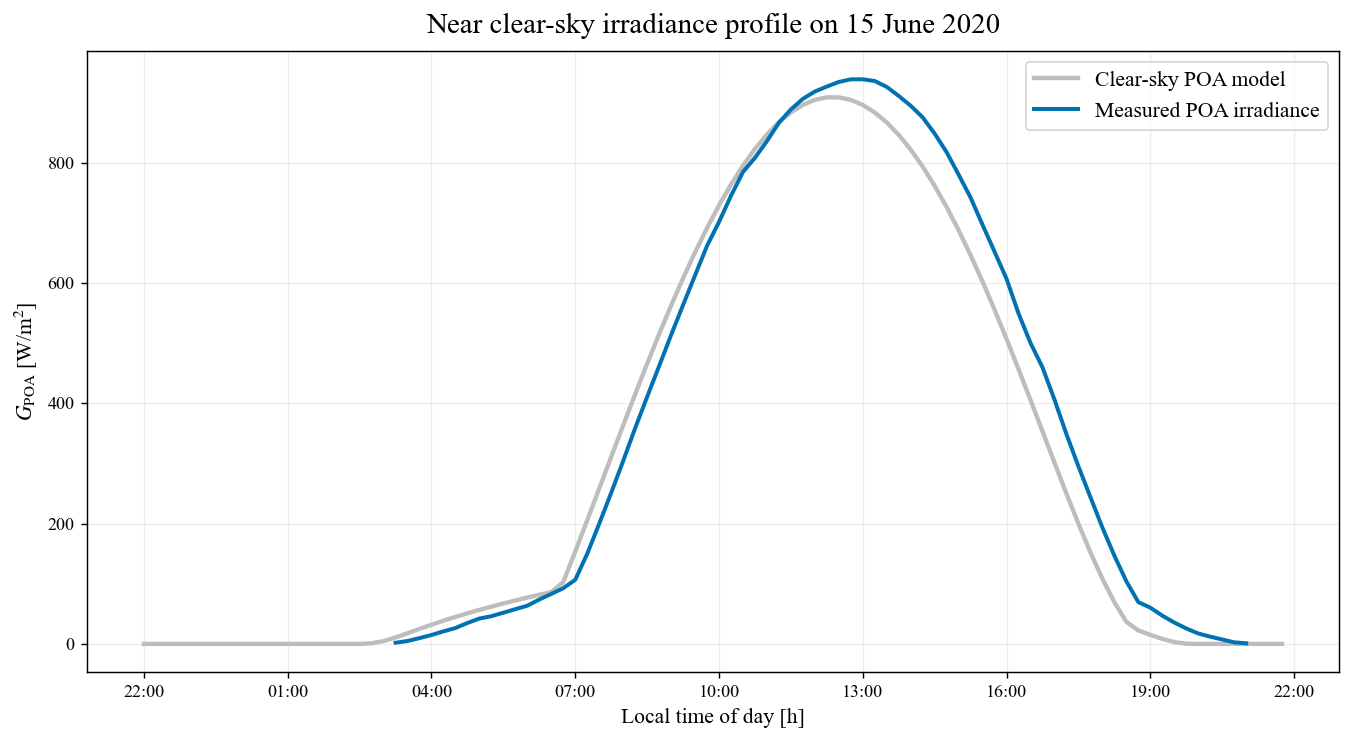

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_partly_clear__variable_irradiance_profile.png


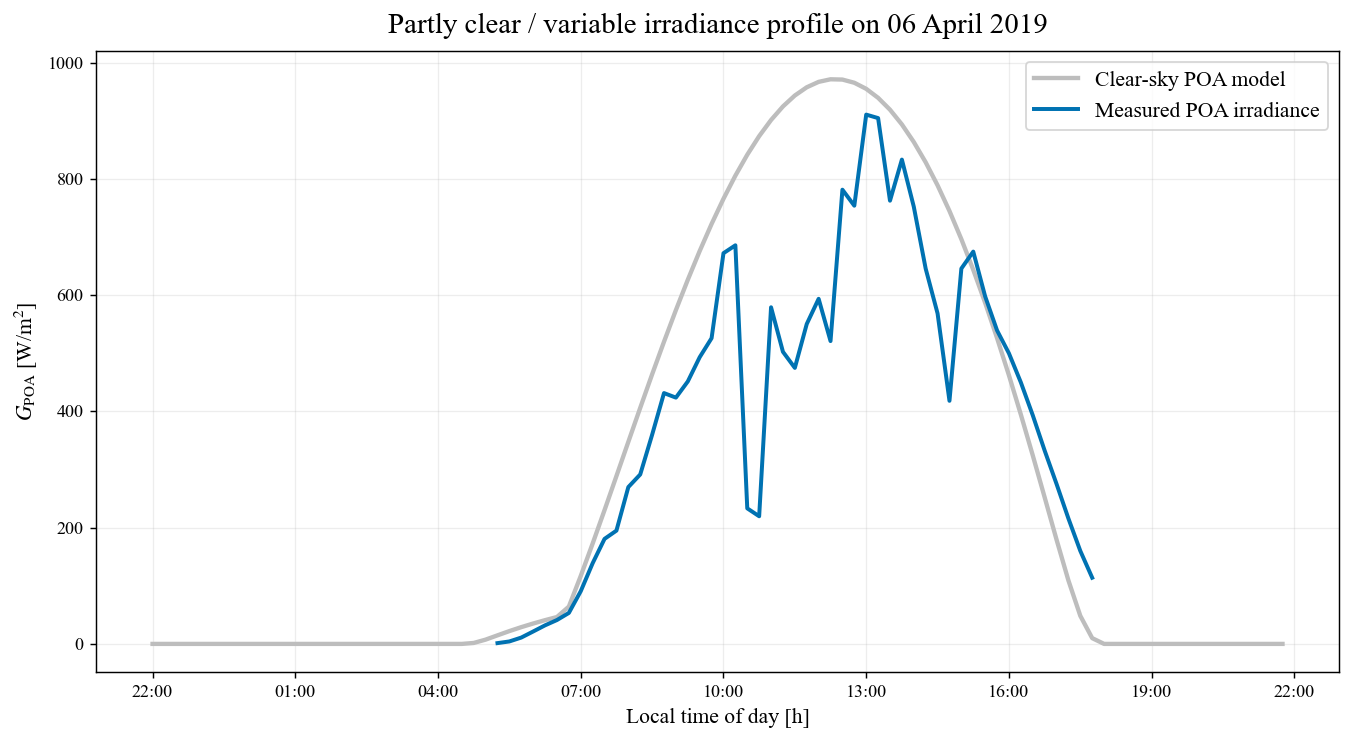

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_highly_variable_irradiance_profile.png


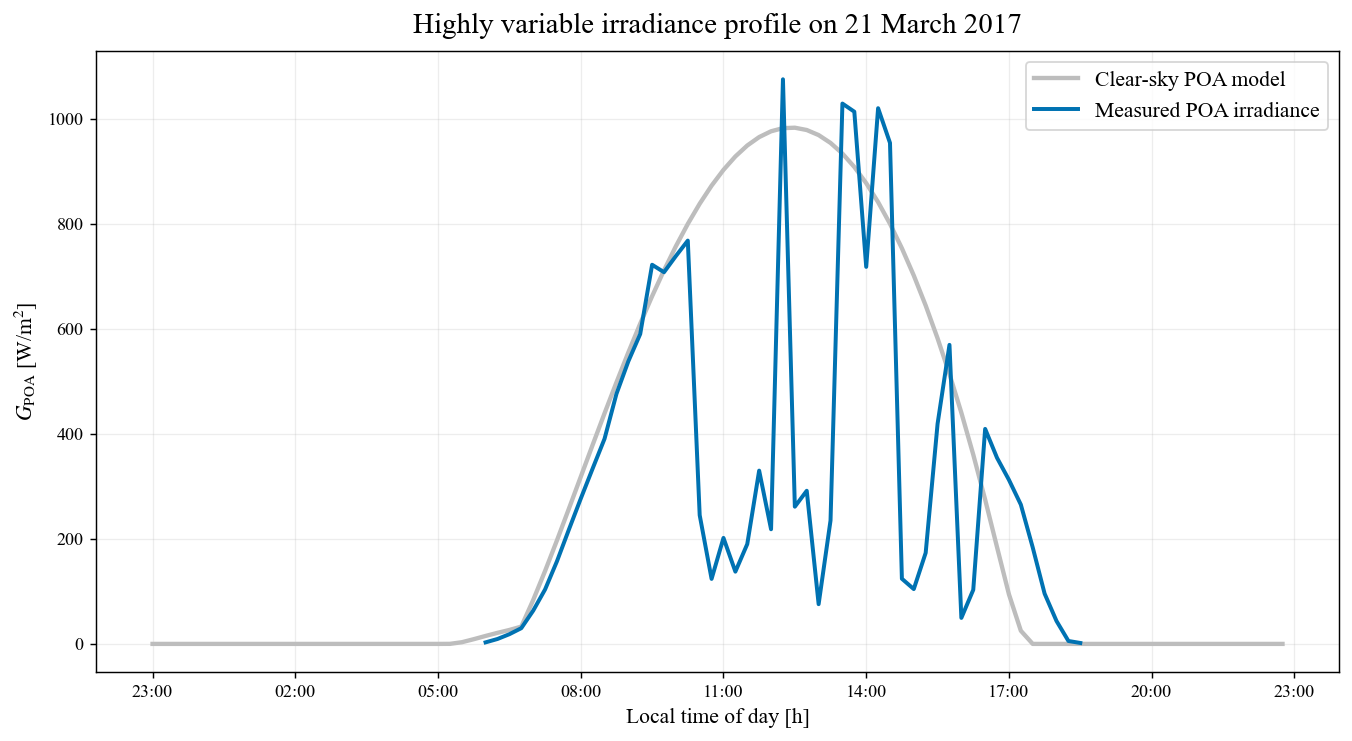

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_cloudy__low_irradiance_irradiance_profile.png


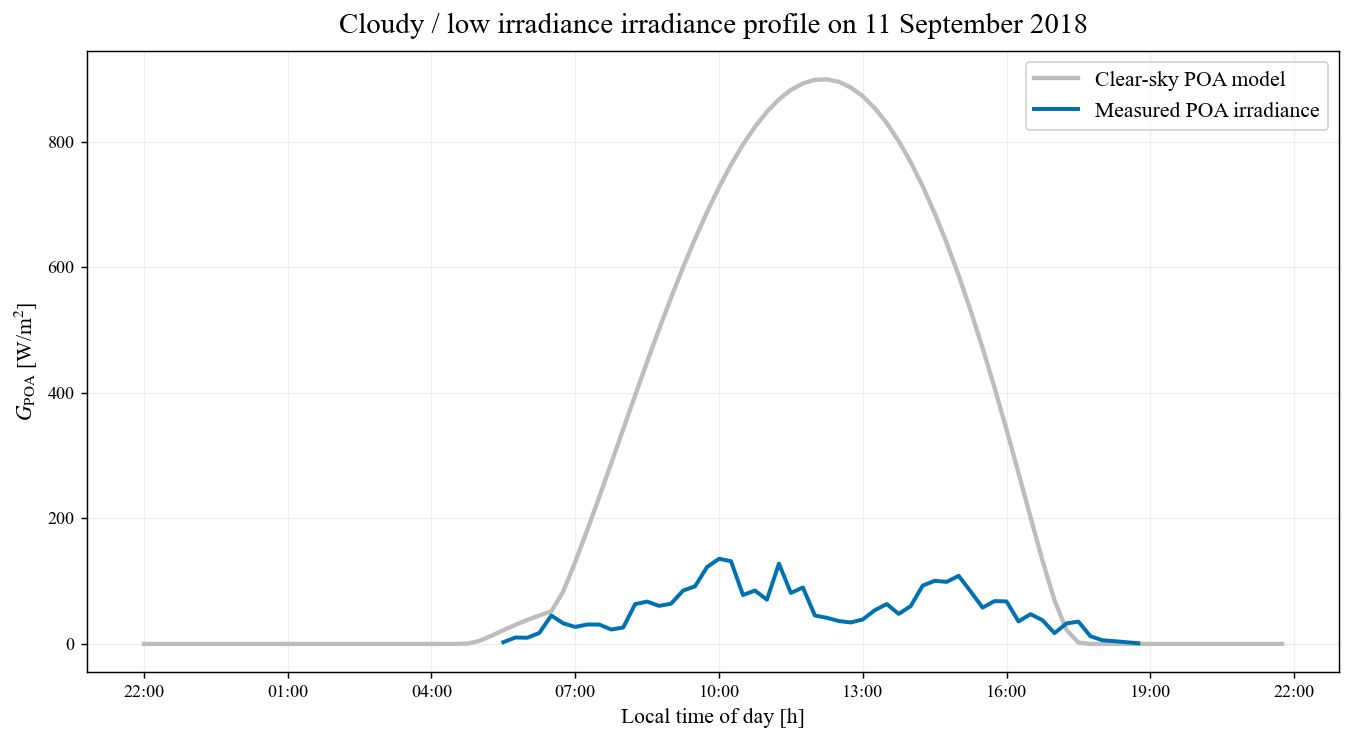

Saved: C:\Users\amina\Thesis\Final Pipeline\figures\final figures\appendix_incomplete__low_coverage_irradiance_profile.png


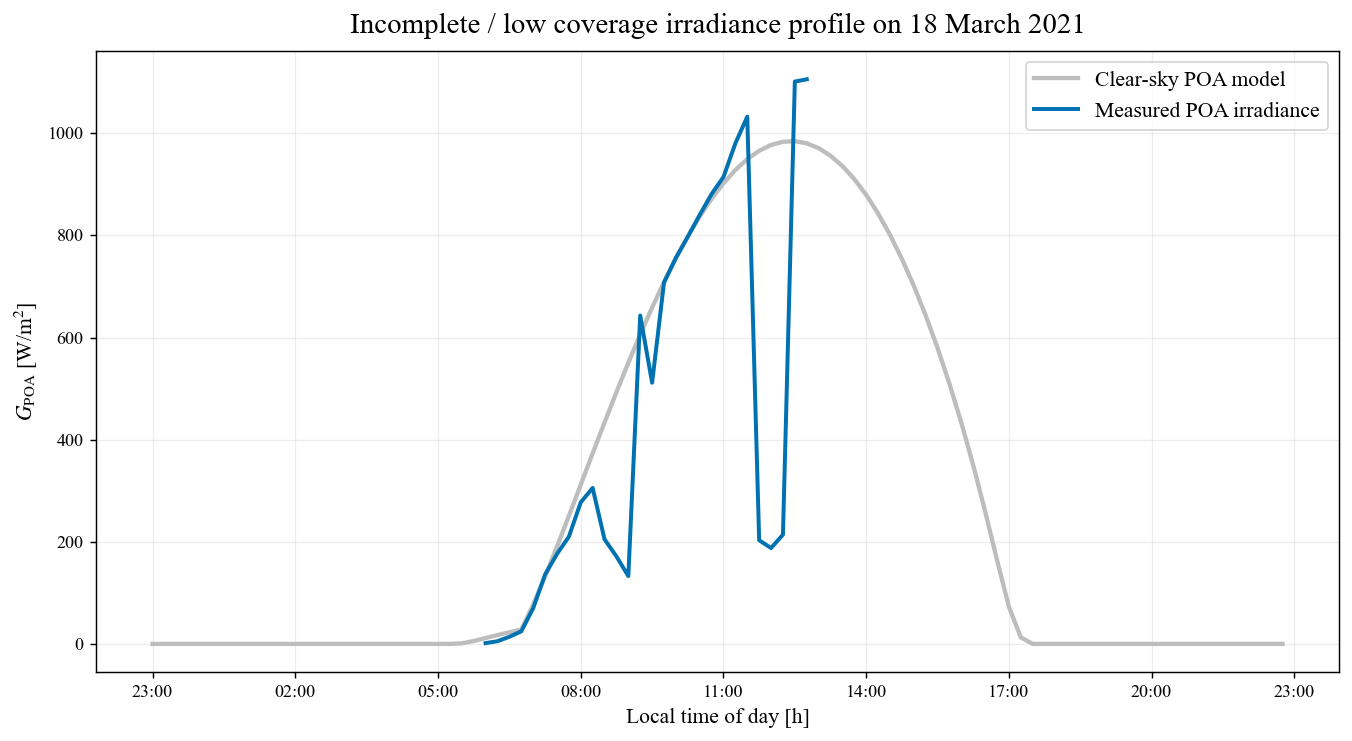

In [34]:
for class_name in CLASS_ORDER:
    if class_name in representative_days:
        safe_name = (
            class_name.lower()
            .replace(" ", "_")
            .replace("/", "")
            .replace("-", "_")
        )

        plot_single_irradiance_class_example(
            class_name=class_name,
            representative_days_input=representative_days,
            save_name=f"appendix_{safe_name}_irradiance_profile.png",
        )

## 13. Create irradiance-filtered row-level datasets

The irradiance-filtering criteria described in Section 3.5.3 are applied to the corrected 2017–2021 dataset.

Three row-level datasets are created:

1. `g200`: daytime rows with (200 <= G_{POA} <= 1200) W/m²;
2. `g400`: daytime rows with (400 <= G_{POA} <= 1200) W/m²;
3. `sunny`: daytime g200 rows from near clear-sky or partly clear days.

These datasets are used in later performance-ratio and PLR calculations.

In [35]:
G200_THRESHOLD = 200
G400_THRESHOLD = 400
G_POA_MAX = 1200

In [36]:
df_qc = df.merge(
    irr_grid[
        [
            "Datetime_Bin_UTC",
            "G_POA_clear_sky",
            "G_POA_measured",
            "solar_apparent_elevation_deg",
            "is_daytime_solar",
            "is_daylight_analysis_bin",
        ]
    ],
    on="Datetime_Bin_UTC",
    how="left",
)

df_qc = df_qc.merge(
    day_classification[["Date_Local", "Irradiance_Class"]],
    on="Date_Local",
    how="left",
)

df_qc["Irradiance_Class"] = df_qc["Irradiance_Class"].astype(str)

g200 = df_qc.loc[
    (df_qc["is_daytime_solar"])
    & (df_qc["G_POA"] >= G200_THRESHOLD)
    & (df_qc["G_POA"] <= G_POA_MAX)
].copy()

g400 = df_qc.loc[
    (df_qc["is_daytime_solar"])
    & (df_qc["G_POA"] >= G400_THRESHOLD)
    & (df_qc["G_POA"] <= G_POA_MAX)
].copy()

sunny = df_qc.loc[
    (df_qc["is_daytime_solar"])
    & (df_qc["G_POA"] >= G200_THRESHOLD)
    & (df_qc["G_POA"] <= G_POA_MAX)
    & (df_qc["Irradiance_Class"].isin(SUNNY_DAY_CLASSES))
].copy()

print("Dataset shapes:")
print("g200:", g200.shape)
print("g400:", g400.shape)
print("sunny:", sunny.shape)

Dataset shapes:
g200: (2186368, 35)
g400: (1421918, 35)
sunny: (1164790, 35)


## 14. Summarise irradiance-filtered datasets

This table summarises the row-level irradiance-filtered datasets. It is used as Table 4.1 in the Results chapter.

In [37]:
def summarise_irradiance_dataset(dataset_name, dataset):
    return {
        "Dataset": dataset_name,
        "Measurements": len(dataset),
        "Median G_POA [W/m²]": round(dataset["G_POA"].median(), 1),
        "Minimum G_POA [W/m²]": round(dataset["G_POA"].min(), 1),
        "Maximum G_POA [W/m²]": round(dataset["G_POA"].max(), 1),
        "Modules retained": dataset["Module_ID"].nunique(),
    }


irradiance_dataset_summary = pd.DataFrame([
    summarise_irradiance_dataset("g200", g200),
    summarise_irradiance_dataset("g400", g400),
    summarise_irradiance_dataset("sunny", sunny),
])

irradiance_dataset_summary["G_POA range [W/m²]"] = (
    irradiance_dataset_summary["Minimum G_POA [W/m²]"].round(0).astype(int).astype(str)
    + "–"
    + irradiance_dataset_summary["Maximum G_POA [W/m²]"].round(0).astype(int).astype(str)
)

display(
    irradiance_dataset_summary[
        [
            "Dataset",
            "Measurements",
            "Median G_POA [W/m²]",
            "G_POA range [W/m²]",
            "Modules retained",
        ]
    ]
)

irradiance_dataset_summary.to_csv(
    FINAL_TABLE_DIR / "irradiance_filtered_row_level_datasets.csv",
    index=False,
)

,Dataset,Measurements,Median G_POA [W/m²],G_POA range [W/m²],Modules retained
0,g200,2186368,553.9,200–1200,10
1,g400,1421918,745.5,400–1200,10
2,sunny,1164790,662.3,200–1200,10


## 15. Save processed datasets

The irradiance-classified dataset and the three irradiance-filtered row-level datasets are saved for downstream performance-ratio calculation.

In [38]:
df_qc.to_parquet(IRRADIANCE_QC_OUTPUT_PATH, index=False)
g200.to_parquet(G200_OUTPUT_PATH, index=False)
g400.to_parquet(G400_OUTPUT_PATH, index=False)
sunny.to_parquet(SUNNY_OUTPUT_PATH, index=False)

print("Saved irradiance QC dataset:", IRRADIANCE_QC_OUTPUT_PATH)
print("Saved g200 dataset:", G200_OUTPUT_PATH)
print("Saved g400 dataset:", G400_OUTPUT_PATH)
print("Saved sunny dataset:", SUNNY_OUTPUT_PATH)

Saved irradiance QC dataset: C:\Users\amina\Thesis\Final Pipeline\data_processed\irradiance_qc\df_irradiance_qc.parquet
Saved g200 dataset: C:\Users\amina\Thesis\Final Pipeline\data_processed\irradiance_qc\df_g200.parquet
Saved g400 dataset: C:\Users\amina\Thesis\Final Pipeline\data_processed\irradiance_qc\df_g400.parquet
Saved sunny dataset: C:\Users\amina\Thesis\Final Pipeline\data_processed\irradiance_qc\df_sunny.parquet
